## Exploratory Data Analysis

### Read data file into dataframe

In [36]:
import pandas as pd

In [48]:
initia_data_set = "https://drive.google.com/uc?id=1uuq9vMYsxD_LOXtsLj3QlM151cco-klJ&export=download"
df = pd.read_csv(initia_data_set)

In [38]:
import pandas as pd

# 1. Load the dataset
# Replace 'collisions_routieres.csv' with your actual file path if it's different
df = pd.read_csv('collisions_routieres.csv')

print(len(df))

# 2. Get counts by Accident Severity (GRAVITE)
# value_counts() automatically counts occurrences of each unique value
severity_counts = df['GRAVITE'].value_counts().reset_index()

# 3. Rename columns for clarity
severity_counts.columns = ['Severity', 'Count']

# 4. Calculate the percentage for each category
total_accidents = severity_counts['Count'].sum()
severity_counts['Percentage'] = (severity_counts['Count'] / total_accidents) * 100

# 5. Display the results
print("--- Accident Severity Summary ---")
print(severity_counts)

# Optional: Map French terms to English for your chart
mapping = {
    'Mortel': 'Fatal',
    'Grave': 'Severe Injuries',
    'Léger': 'Minor Injuries',
    'Dommages matériels seulement': 'Property Damage (Major)',
    'Dommages matériels inférieurs au seuil de rapportage': 'Property Damage (Minor)'
}

severity_counts['Severity_EN'] = severity_counts['Severity'].map(mapping)

print("\n--- Translated Summary ---")
print(severity_counts[['Severity_EN', 'Count', 'Percentage']])

218272
--- Accident Severity Summary ---
                                            Severity  Count  Percentage
0  Dommages matériels inférieurs au seuil de rapp...  87072   39.891512
1                       Dommages matériels seulement  83226   38.129490
2                                              Léger  45925   21.040262
3                                              Grave   1786    0.818245
4                                             Mortel    263    0.120492

--- Translated Summary ---
               Severity_EN  Count  Percentage
0  Property Damage (Minor)  87072   39.891512
1  Property Damage (Major)  83226   38.129490
2           Minor Injuries  45925   21.040262
3          Severe Injuries   1786    0.818245
4                    Fatal    263    0.120492


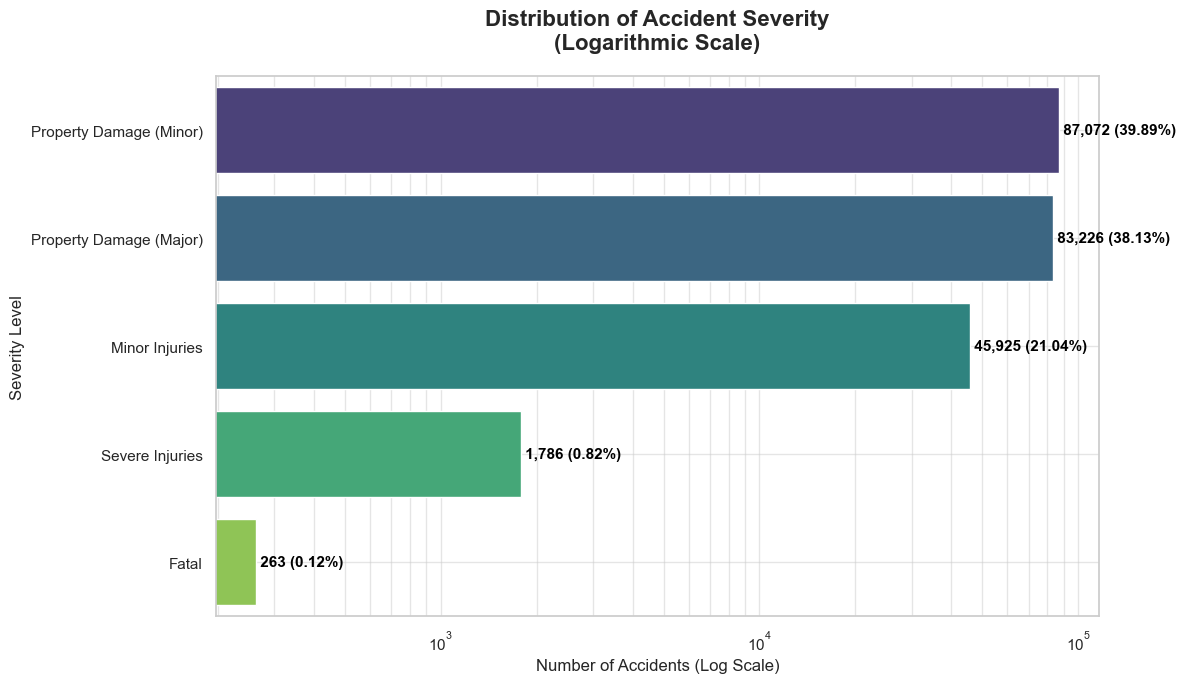

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = {
    'Severity': ['Fatal', 'Severe Injuries', 'Minor Injuries', 
                 'Property Damage (Major)', 'Property Damage (Minor)'],
    'Count': [263, 1786, 45925, 83226, 87072]
}
df_plot = pd.DataFrame(data).sort_values(by='Count', ascending=False)

# Set visual style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# FIX: Assign 'Severity' to 'hue', set 'legend=False', and pass 'palette'
sns.barplot(
    x='Count', 
    y='Severity', 
    data=df_plot, 
    hue='Severity',    # Assigning the y-variable to hue
    palette='viridis', 
    legend=False,      # Removes the redundant legend
    ax=ax
)

# Use Logarithmic X-axis
ax.set_xscale("log")

# Add precise labels (Count and Percentage)
total = df_plot['Count'].sum()
for i, count in enumerate(df_plot['Count']):
    pct = (count / total) * 100
    ax.text(count, i, f' {count:,} ({pct:.2f}%)', 
            va='center', fontweight='bold', color='black', fontsize=11)

ax.set_title("Distribution of Accident Severity\n(Logarithmic Scale)", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Number of Accidents (Log Scale)", fontsize=12)
ax.set_ylabel("Severity Level", fontsize=12)
ax.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.savefig('distribution_of_accident_severity.png')
plt.show()

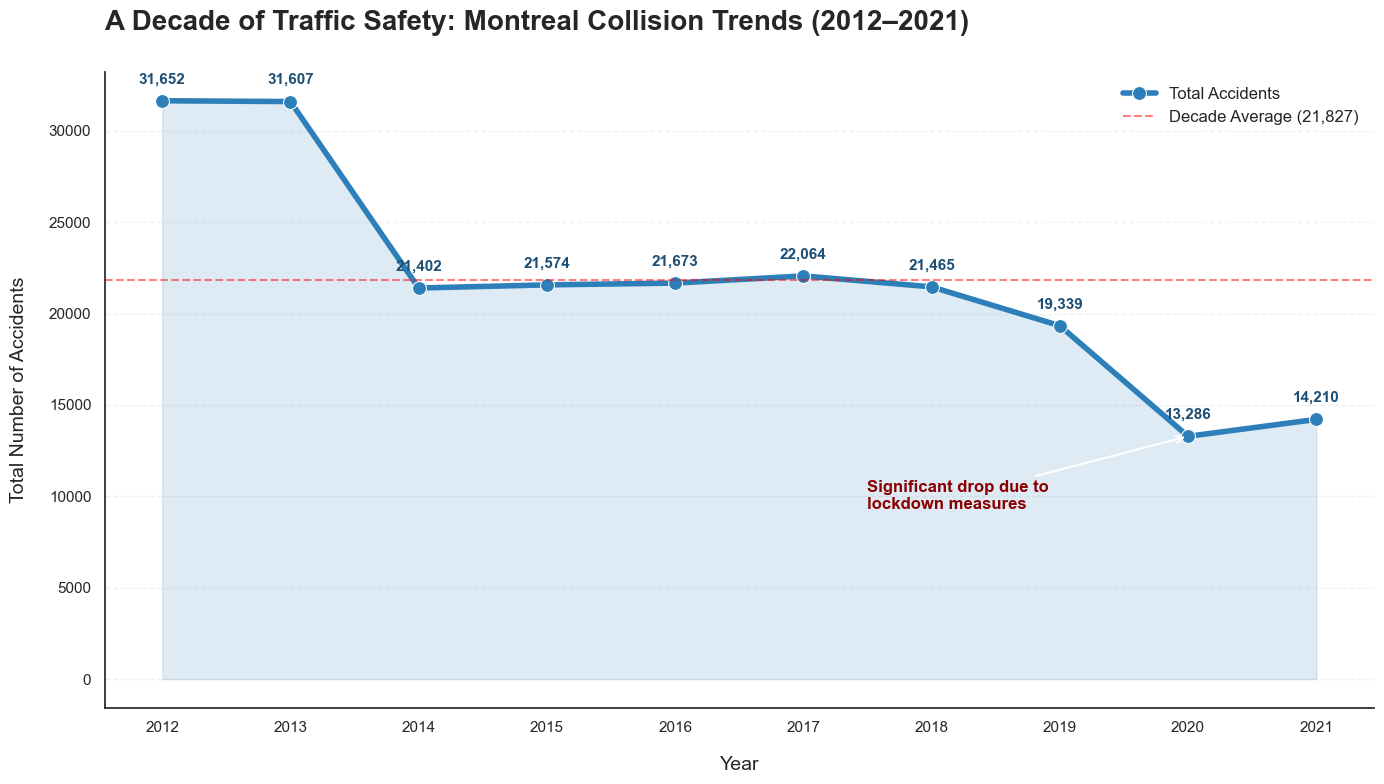

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data and calculate the trend
df = pd.read_csv('collisions_routieres.csv')
yearly_trend = df.groupby('AN').size().reset_index(name='accident_count')

# Calculate the mean for context
mean_val = yearly_trend['accident_count'].mean()

# 2. Setup the visual style
sns.set_theme(style="white") # Cleaner background
fig, ax = plt.subplots(figsize=(14, 8))

# 3. Plot Area (The "Fill" effect)
plt.fill_between(yearly_trend['AN'], yearly_trend['accident_count'], color="#2c7fb8", alpha=0.15)

# 4. Plot the main line with styling
sns.lineplot(
    data=yearly_trend, 
    x='AN', 
    y='accident_count', 
    marker='o', 
    markersize=10, 
    linewidth=4, 
    color='#2c7fb8',
    label='Total Accidents'
)

# 5. Add a Baseline (Average line)
plt.axhline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'Decade Average ({int(mean_val):,})')

# 6. Highlight & Annotate 2020 (The COVID-19 Drop)
covid_val = yearly_trend[yearly_trend['AN'] == 2020]['accident_count'].values[0]
plt.annotate('Significant drop due to\nlockdown measures', 
             xy=(2020, covid_val), 
             xytext=(2017.5, covid_val - 4000),
             fontsize=12, fontweight='bold', color='darkred',
             arrowprops=dict(facecolor='darkred', arrowstyle='->', lw=1.5))

# 7. Add professional data labels
for x, y in zip(yearly_trend['AN'], yearly_trend['accident_count']):
    ax.text(x, y + 800, f'{y:,}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1e5075')

# 8. Final touches (Title, Axes, Spines)
ax.set_title('A Decade of Traffic Safety: Montreal Collision Trends (2012–2021)', 
             fontsize=20, fontweight='bold', pad=30, loc='left')
ax.set_xlabel('Year', fontsize=14, labelpad=15)
ax.set_ylabel('Total Number of Accidents', fontsize=14, labelpad=15)
ax.set_xticks(yearly_trend['AN'])

# Remove top and right borders for a modern look
sns.despine()

# Add a subtle grid on the y-axis only
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Legend without the box
plt.legend(frameon=False, loc='upper right', fontsize=12)

plt.tight_layout()
plt.savefig('interesting_accident_trend.png', dpi=300)
plt.show()

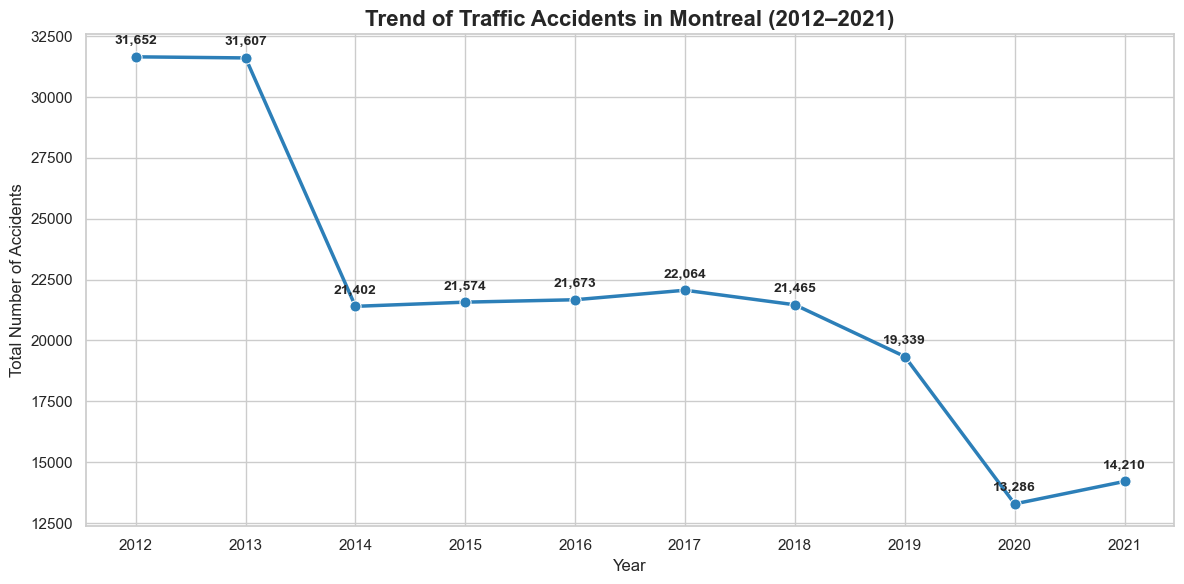

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('collisions_routieres.csv')

# Group the data by year ('AN') and count the number of accidents
yearly_trend = df.groupby('AN').size().reset_index(name='accident_count')

# Set the visual theme
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(12, 6))

# Plot the trend with a line and markers
sns.lineplot(
    data=yearly_trend, 
    x='AN', 
    y='accident_count', 
    marker='o', 
    markersize=8, 
    linewidth=2.5, 
    color='#2c7fb8'
)

# Customize the chart for professional look
plt.title('Trend of Traffic Accidents in Montreal (2012–2021)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Number of Accidents', fontsize=12)

# Ensure every year is labeled on the X-axis
plt.xticks(yearly_trend['AN'])

# Add data labels above each marker for exact counts
for x, y in zip(yearly_trend['AN'], yearly_trend['accident_count']):
    plt.text(x, y + 400, f'{y:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Optimize layout and save
plt.tight_layout()
plt.savefig('accident_trend_over_years.png')
plt.show()

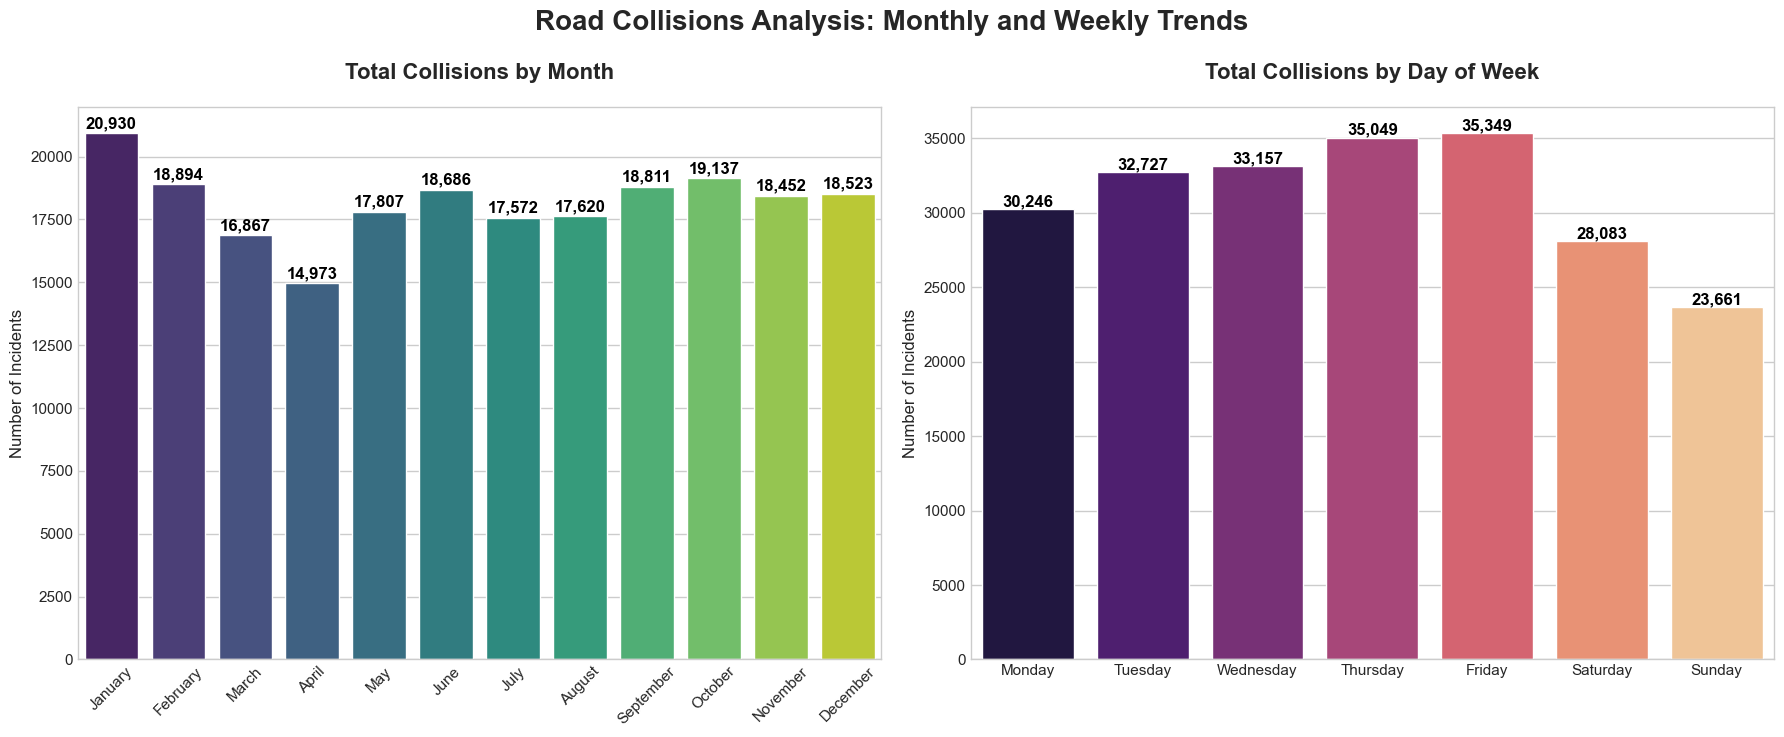

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Ensure the file 'collisions_routieres.csv' is in your working directory
df = pd.read_csv('collisions_routieres.csv')

# 2. Preprocess the date information
# Convert 'DT_ACCDN' to datetime objects
df['DT_ACCDN'] = pd.to_datetime(df['DT_ACCDN'])

# Extract Month and Day of the week
df['Month_Name'] = df['DT_ACCDN'].dt.month_name()
df['Day_Name'] = df['DT_ACCDN'].dt.day_name()

# 3. Aggregate data for the Monthly Display
# Define the order of months for a logical timeline
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
monthly_data = df.groupby('Month_Name').size().reindex(month_order)

# 4. Aggregate data for the Weekly Display
# Define the order of days starting from Monday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_data = df.groupby('Day_Name').size().reindex(day_order)

# 5. Create the Visualization
# Set a professional style
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Monthly Seasonality (Bar Chart) ---
sns.barplot(x=monthly_data.index, y=monthly_data.values, ax=ax1, palette='viridis', hue=monthly_data.index, legend=False)
ax1.set_title('Total Collisions by Month', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Number of Incidents', fontsize=12)
ax1.set_xlabel('', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on top of bars
for i, v in enumerate(monthly_data.values):
    ax1.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold', color='black')

# --- Plot 2: Weekly Breakdown (Bar Chart) ---
sns.barplot(x=weekly_data.index, y=weekly_data.values, ax=ax2, palette='magma', hue=weekly_data.index, legend=False)
ax2.set_title('Total Collisions by Day of Week', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel('Number of Incidents', fontsize=12)
ax2.set_xlabel('', fontsize=12)

# Add value labels on top of bars
for i, v in enumerate(weekly_data.values):
    ax2.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold', color='black')

# Final formatting
plt.tight_layout()
plt.suptitle('Road Collisions Analysis: Monthly and Weekly Trends', fontsize=20, y=1.05, fontweight='bold')

# Save and show the result
plt.savefig('collision_overview_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\mthakur\AppData\Local\Temp\ipykernel_54812\36891691.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette='plasma')


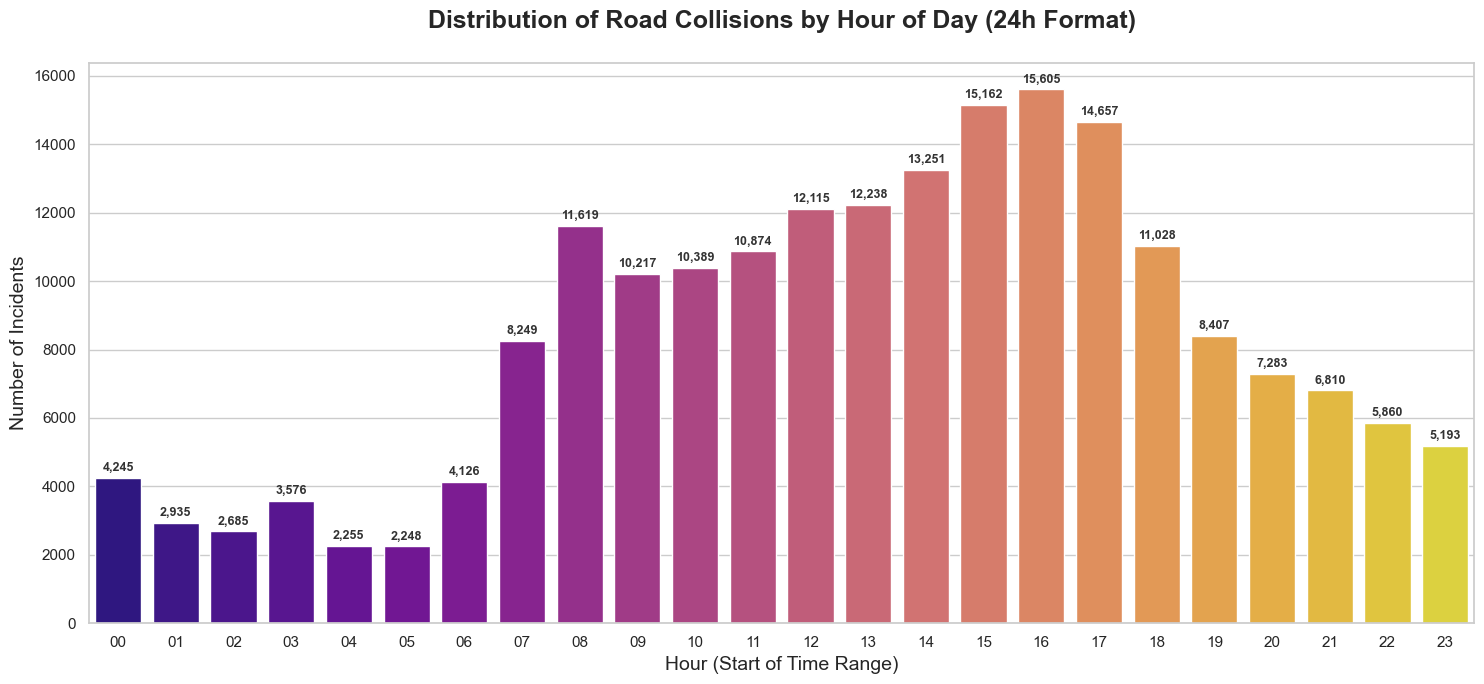

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('collisions_routieres.csv')

# 2. Preprocess the time data
# Filter out 'Non précisé' and create a copy to avoid warnings
hourly_data = df[df['HEURE_ACCDN'] != 'Non précisé'].copy()

# Extract the first two characters (the starting hour) from the range
# Example: '16:00:00-16:59:00' becomes '16'
hourly_data['Hour'] = hourly_data['HEURE_ACCDN'].str[:2]

# 3. Group and count collisions by hour
hourly_counts = hourly_data.groupby('Hour').size().sort_index()

# 4. Create the Visualization
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

# Create a bar plot with a 'plasma' color palette
ax = sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette='plasma')

# Title and labels
plt.title('Distribution of Road Collisions by Hour of Day (24h Format)', 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Hour (Start of Time Range)', fontsize=14)
plt.ylabel('Number of Incidents', fontsize=14)

# 5. Add data labels on top of each bar for clarity
for i, v in enumerate(hourly_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9, fontweight='bold', color='#333')

# Final adjustments
plt.tight_layout()
plt.savefig('hourly_distribution.png', dpi=300)
plt.show()

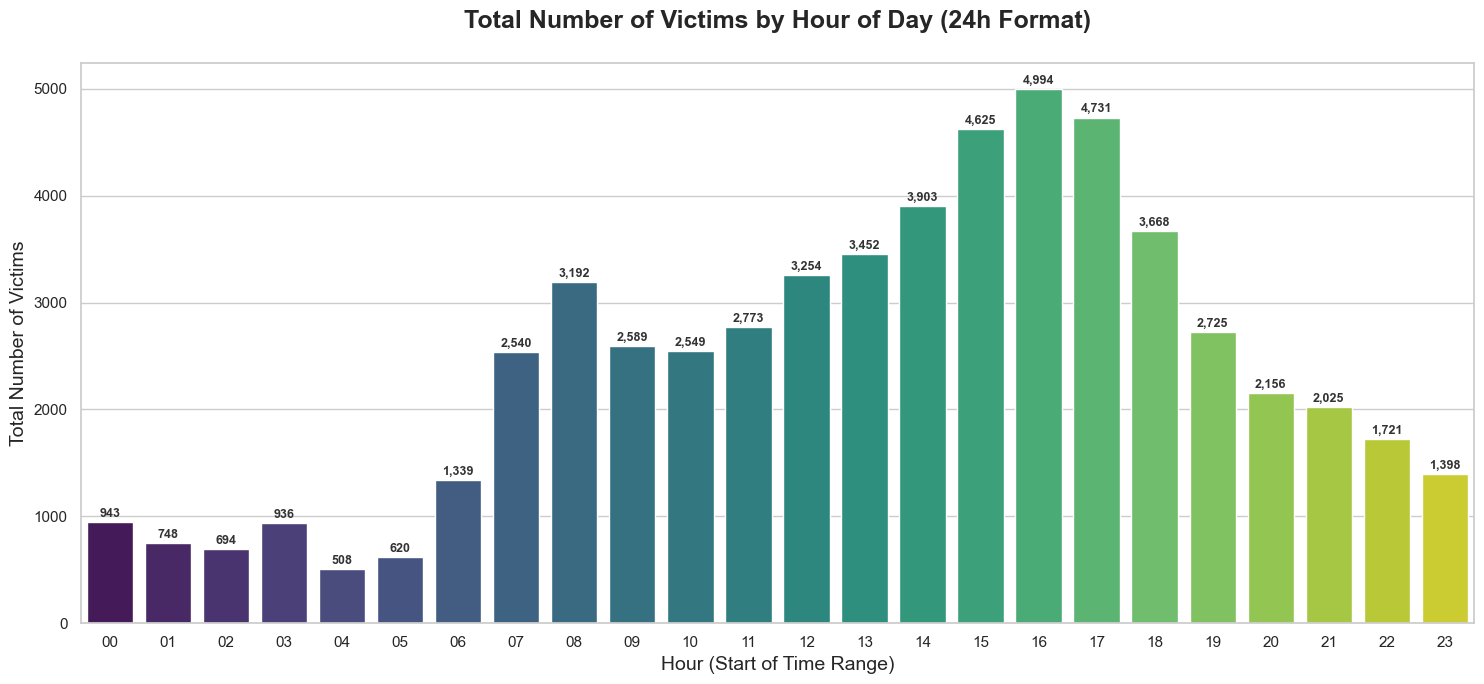

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('collisions_routieres.csv')

# 2. Preprocess the data
# Filter out 'Non précisé' and extract the starting hour
hourly_data = df[df['HEURE_ACCDN'] != 'Non précisé'].copy()
hourly_data['Hour'] = hourly_data['HEURE_ACCDN'].str[:2]

# 3. Group by hour and SUM the total victims (NB_VICTIMES_TOTAL)
# This counts the total number of people affected rather than just the number of crashes
hourly_victims = hourly_data.groupby('Hour')['NB_VICTIMES_TOTAL'].sum().sort_index()

# 4. Create the Visualization
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

# Assigning x to hue and setting legend=False to prevent warnings in newer Seaborn versions
ax = sns.barplot(
    x=hourly_victims.index, 
    y=hourly_victims.values, 
    palette='viridis', 
    hue=hourly_victims.index,
    legend=False
)

# 5. Styling and Labels
plt.title('Total Number of Victims by Hour of Day (24h Format)', 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Hour (Start of Time Range)', fontsize=14)
plt.ylabel('Total Number of Victims', fontsize=14)

# Adding data labels (total victims) on top of each bar
for i, v in enumerate(hourly_victims.values):
    ax.text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9, fontweight='bold', color='#333')

# Final formatting
plt.tight_layout()
plt.savefig('hourly_victims_distribution.png', dpi=300)
plt.show()

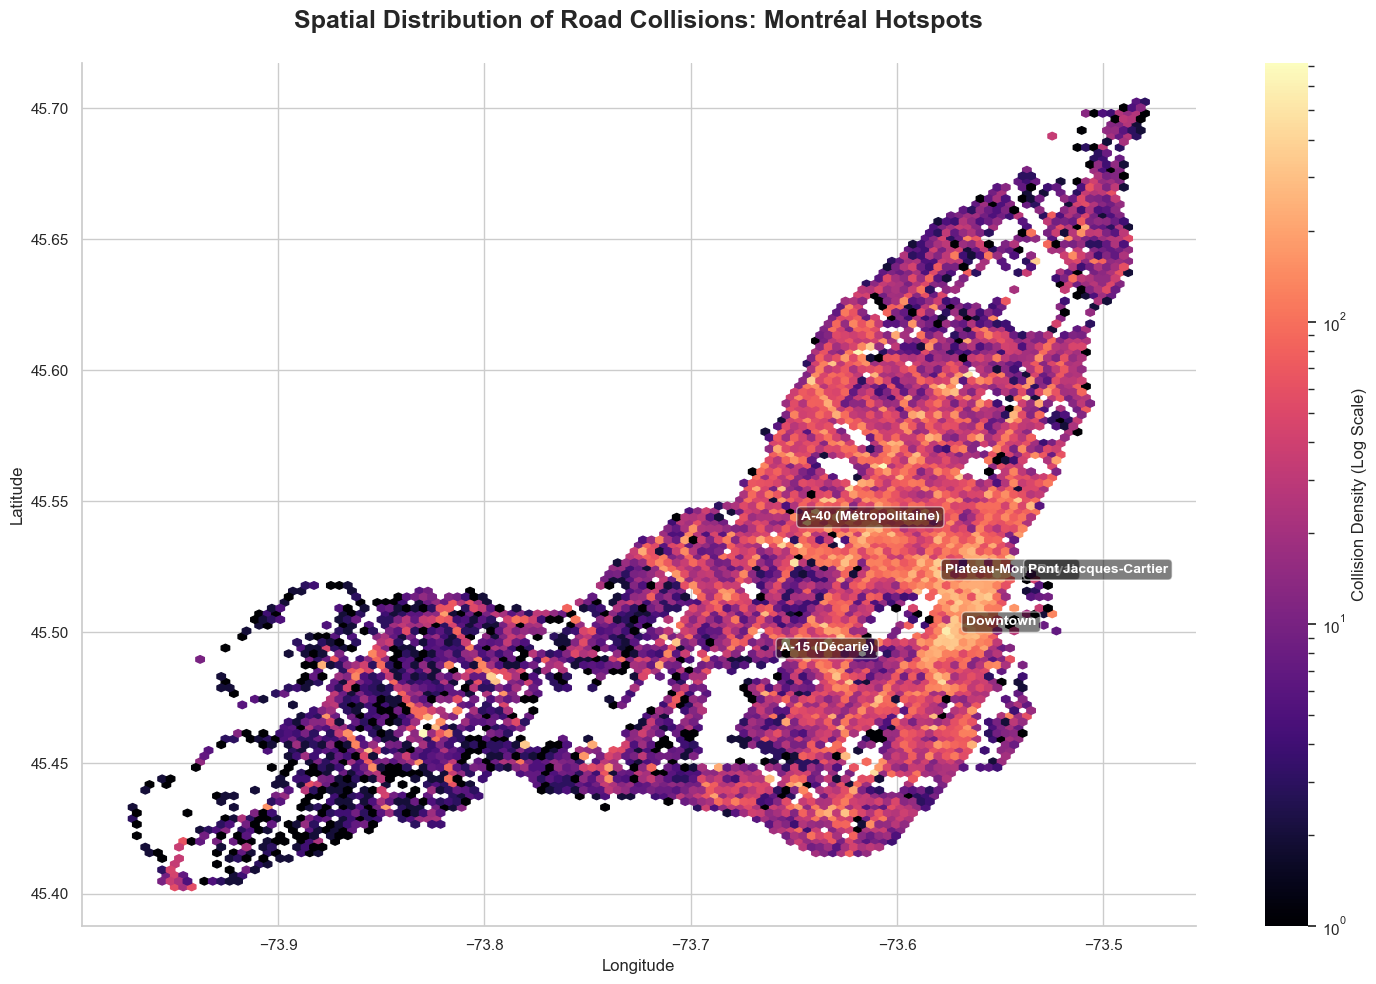

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('collisions_routieres.csv')

# 2. Clean spatial data
# Remove rows with missing coordinates
spatial_df = df.dropna(subset=['LOC_LONG', 'LOC_LAT']).copy()

# Filter coordinates to focus on the Montreal Island area (removes outliers)
spatial_df = spatial_df[
    (spatial_df['LOC_LONG'] > -74.1) & (spatial_df['LOC_LONG'] < -73.4) &
    (spatial_df['LOC_LAT'] > 45.3) & (spatial_df['LOC_LAT'] < 45.8)
]

# 3. Create the Visualization
plt.figure(figsize=(15, 10), facecolor='white')

# Use hexbin for the "H3-like" hexagonal clustering
# gridsize: Controls the size of the hexagons (higher = smaller/more detailed)
# bins='log': Helps visualize both small and large concentrations effectively
hb = plt.hexbin(
    spatial_df['LOC_LONG'], 
    spatial_df['LOC_LAT'], 
    gridsize=120, 
    cmap='magma', 
    mincnt=1, 
    bins='log' 
)

# Add a colorbar
cb = plt.colorbar(hb, ax=plt.gca(), label='Collision Density (Log Scale)')
cb.outline.set_visible(False)

# 4. Styling and Annotations
plt.title('Spatial Distribution of Road Collisions: Montréal Hotspots', 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Remove axis spines for a cleaner map look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Approximate landmarks for context (optional annotations)
landmarks = {
    'Downtown': (-73.57, 45.50),
    'Plateau-Mont-Royal': (-73.58, 45.52),
    'A-40 (Métropolitaine)': (-73.65, 45.54),
    'A-15 (Décarie)': (-73.66, 45.49),
    'Pont Jacques-Cartier': (-73.54, 45.52)
}

for name, coords in landmarks.items():
    plt.annotate(name, xy=coords, xytext=(5, 5), textcoords='offset points', 
                 fontsize=10, fontweight='bold', color='white', 
                 bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.5))

# 5. Finalize and Save
plt.tight_layout()
plt.savefig('spatial_hotspots_hexbin.png', dpi=300)
plt.show()

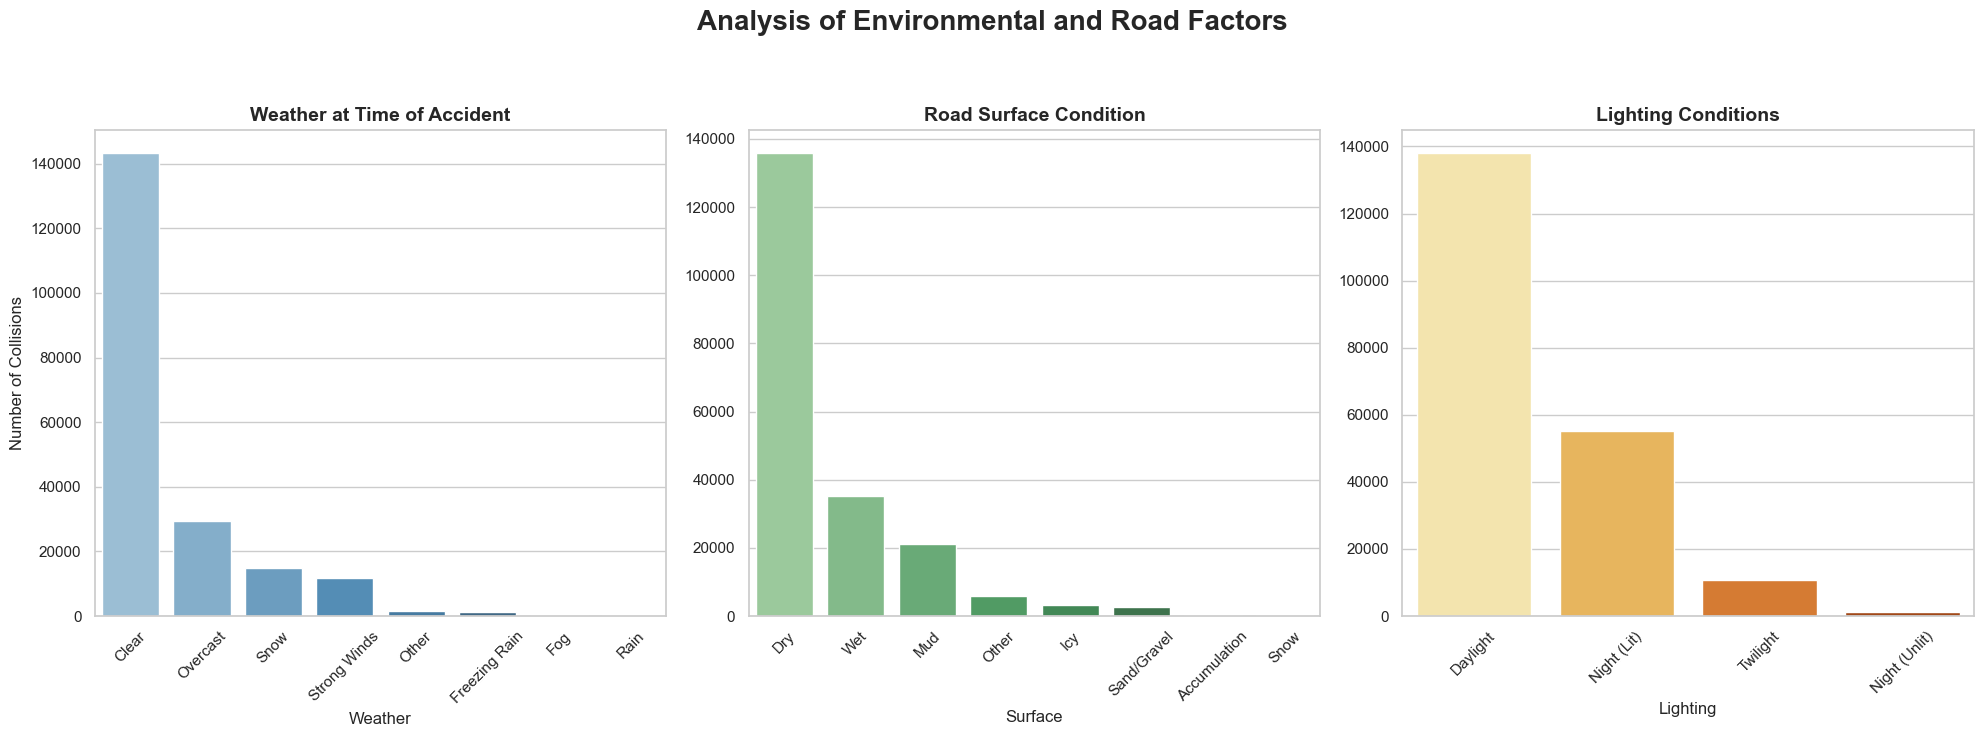

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('collisions_routieres.csv')

# 2. Define human-readable mappings based on Quebec road data standards
meteo_map = {
    11.0: "Clear", 12.0: "Overcast", 13.0: "Rain", 14.0: "Snow", 
    15.0: "Freezing Rain", 16.0: "Fog", 17.0: "Strong Winds", 18.0: "Other"
}
surface_map = {
    11.0: "Dry", 12.0: "Wet", 13.0: "Accumulation", 14.0: "Snow", 
    15.0: "Icy", 16.0: "Mud", 17.0: "Sand/Gravel", 18.0: "Other"
}
light_map = {
    1.0: "Daylight", 2.0: "Twilight", 3.0: "Night (Lit)", 4.0: "Night (Unlit)"
}

# 3. Apply the mappings
df['Weather'] = df['CD_COND_METEO'].map(meteo_map)
df['Surface'] = df['CD_ETAT_SURFC'].map(surface_map)
df['Lighting'] = df['CD_ECLRM'].map(light_map)

# 4. Create the Visualization Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Plot 1: Weather Conditions ---
meteo_counts = df['Weather'].value_counts()
sns.barplot(x=meteo_counts.index, y=meteo_counts.values, ax=axes[0], 
            palette='Blues_d', hue=meteo_counts.index, legend=False)
axes[0].set_title('Weather at Time of Accident', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Number of Collisions')

# --- Plot 2: Road Surface ---
surf_counts = df['Surface'].value_counts()
sns.barplot(x=surf_counts.index, y=surf_counts.values, ax=axes[1], 
            palette='Greens_d', hue=surf_counts.index, legend=False)
axes[1].set_title('Road Surface Condition', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# --- Plot 3: Lighting ---
light_counts = df['Lighting'].value_counts()
sns.barplot(x=light_counts.index, y=light_counts.values, ax=axes[2], 
            palette='YlOrBr', hue=light_counts.index, legend=False)
axes[2].set_title('Lighting Conditions', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

# 5. Finalize and Save
plt.suptitle('Analysis of Environmental and Road Factors', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('environmental_road_factors.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\mthakur\AppData\Local\Temp\ipykernel_54812\3898315099.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


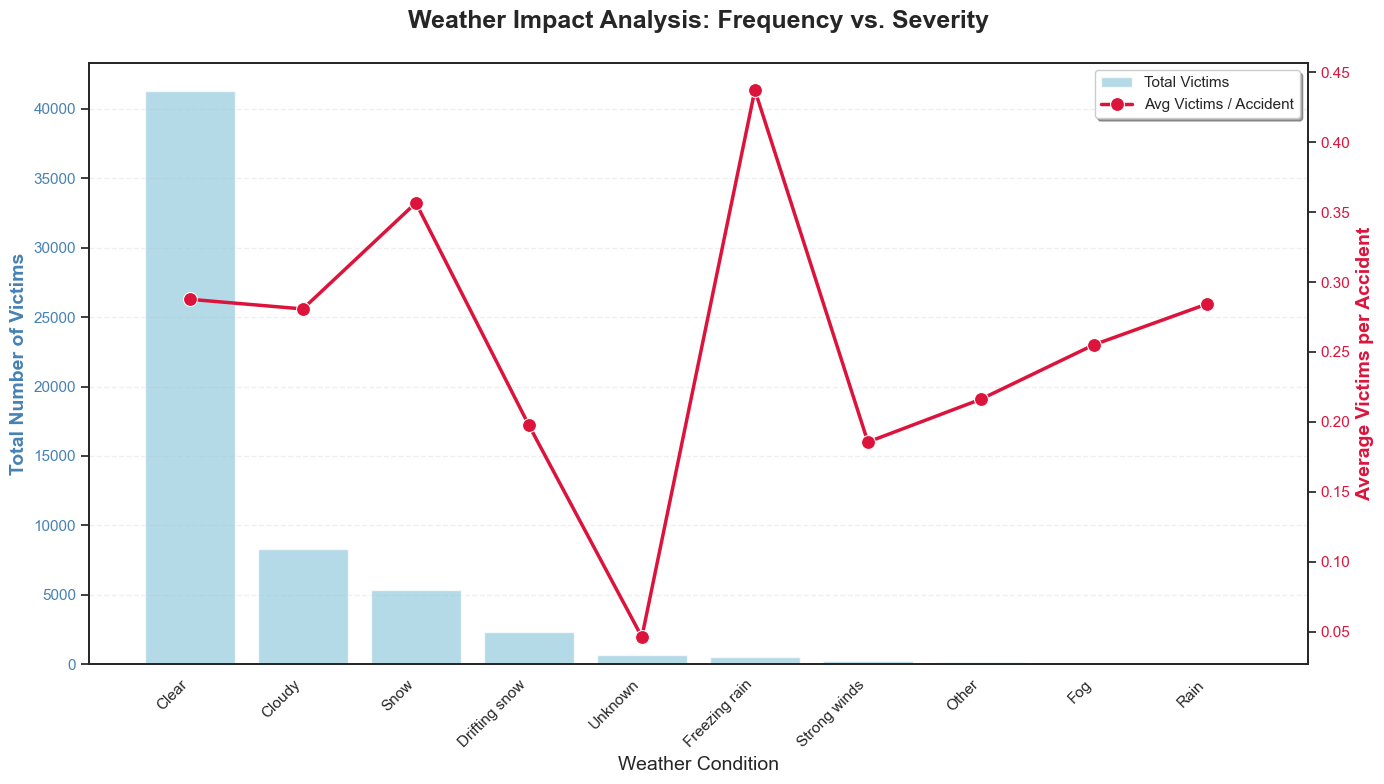

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('collisions_routieres.csv')

# 2. Preprocess weather codes (SAAQ Mapping)
weather_map = {
    11: 'Clear', 12: 'Cloudy', 13: 'Rain', 14: 'Snow', 
    15: 'Freezing rain', 16: 'Fog', 17: 'Drifting snow', 
    18: 'Strong winds', 19: 'Other', 99: 'Unknown'
}
df['Weather'] = pd.to_numeric(df['CD_COND_METEO'], errors='coerce').fillna(99).astype(int).map(weather_map)

# 3. Calculate both statistics
weather_stats = df.groupby('Weather').agg(
    Total_Victims=('NB_VICTIMES_TOTAL', 'sum'),
    Average_Victims=('NB_VICTIMES_TOTAL', 'mean')
).reset_index().sort_values(by='Total_Victims', ascending=False)

# 4. Create the Combined Dual-Axis Graph
fig, ax1 = plt.subplots(figsize=(14, 8))
sns.set_theme(style="white")

# Primary Axis: Total Victims (Bars)
sns.barplot(x='Weather', y='Total_Victims', data=weather_stats, color='skyblue', alpha=0.7, ax=ax1, label='Total Victims')
ax1.set_ylabel('Total Number of Victims', fontsize=14, fontweight='bold', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlabel('Weather Condition', fontsize=14)

# Secondary Axis: Average Victims (Line)
ax2 = ax1.twinx()
sns.lineplot(x='Weather', y='Average_Victims', data=weather_stats, marker='o', color='crimson', linewidth=2.5, markersize=10, ax=ax2, label='Avg Victims / Accident')
ax2.set_ylabel('Average Victims per Accident', fontsize=14, fontweight='bold', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# 5. Formatting and Legend
plt.title('Weather Impact Analysis: Frequency vs. Severity', fontsize=18, fontweight='bold', pad=25)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Combine legends from both axes into one box
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper right', frameon=True, shadow=True)

ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('combined_weather_impact.png', dpi=300)
plt.show()

C:\Users\mthakur\AppData\Local\Temp\ipykernel_54812\2306130183.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


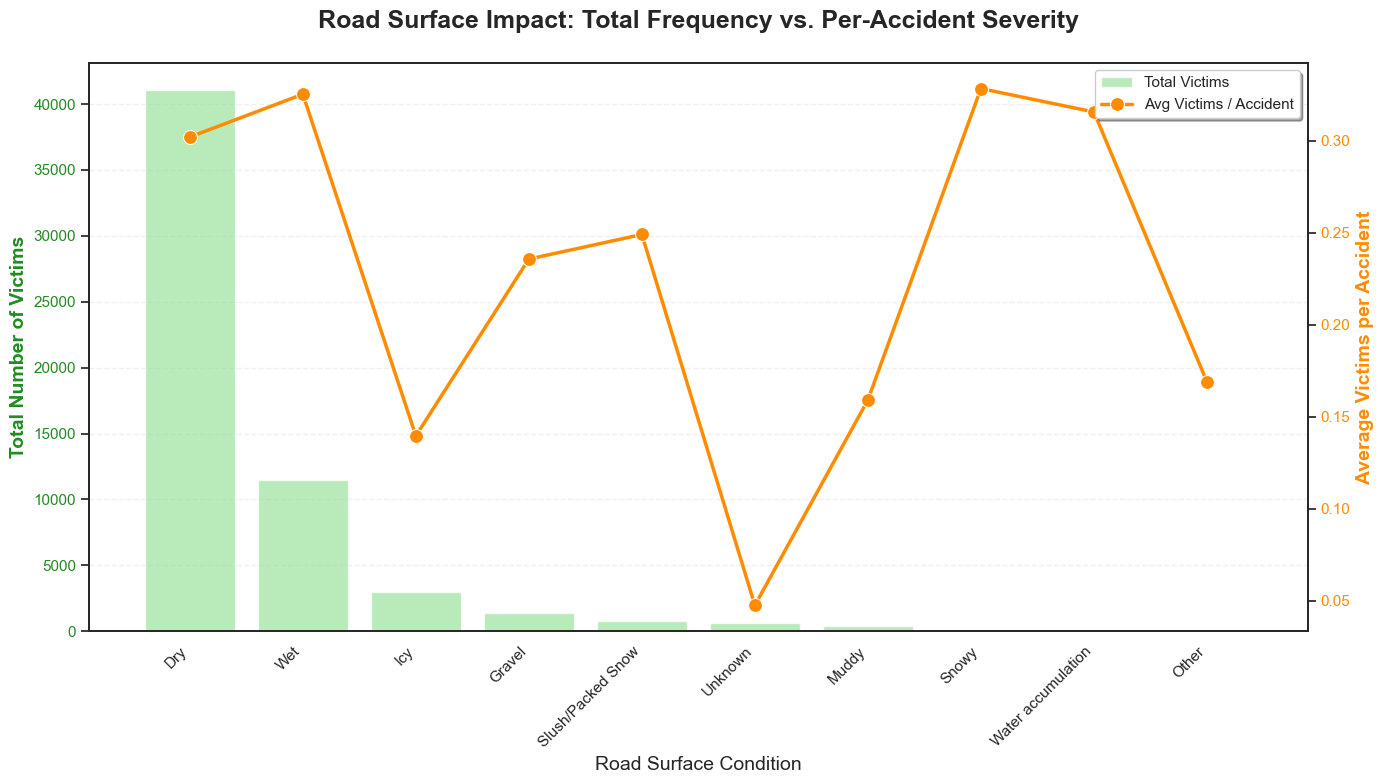

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('collisions_routieres.csv')

# 2. Preprocess surface codes (SAAQ Mapping for CD_ETAT_SURFC)
surface_map = {
    11: 'Dry', 12: 'Wet', 13: 'Water accumulation',
    14: 'Snowy', 15: 'Slush/Packed Snow', 16: 'Icy',
    17: 'Muddy', 18: 'Gravel', 19: 'Other', 99: 'Unknown'
}
df['Surface'] = pd.to_numeric(df['CD_ETAT_SURFC'], errors='coerce').fillna(99).astype(int).map(surface_map)

# 3. Calculate statistics
surface_stats = df.groupby('Surface').agg(
    Total_Victims=('NB_VICTIMES_TOTAL', 'sum'),
    Average_Victims=('NB_VICTIMES_TOTAL', 'mean')
).reset_index().sort_values(by='Total_Victims', ascending=False)

# 4. Create the Combined Dual-Axis Graph
fig, ax1 = plt.subplots(figsize=(14, 8))
sns.set_theme(style="white")

# Primary Axis: Total Victims (Bars)
sns.barplot(x='Surface', y='Total_Victims', data=surface_stats, color='lightgreen', alpha=0.7, ax=ax1, label='Total Victims')
ax1.set_ylabel('Total Number of Victims', fontsize=14, fontweight='bold', color='forestgreen')
ax1.tick_params(axis='y', labelcolor='forestgreen')
ax1.set_xlabel('Road Surface Condition', fontsize=14)

# Secondary Axis: Average Victims (Line)
ax2 = ax1.twinx()
sns.lineplot(x='Surface', y='Average_Victims', data=surface_stats, marker='o', color='darkorange', linewidth=2.5, markersize=10, ax=ax2, label='Avg Victims / Accident')
ax2.set_ylabel('Average Victims per Accident', fontsize=14, fontweight='bold', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# 5. Formatting
plt.title('Road Surface Impact: Total Frequency vs. Per-Accident Severity', fontsize=18, fontweight='bold', pad=25)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Combine legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper right', frameon=True, shadow=True)

ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('surface_impact_analysis.png', dpi=300)
plt.show()

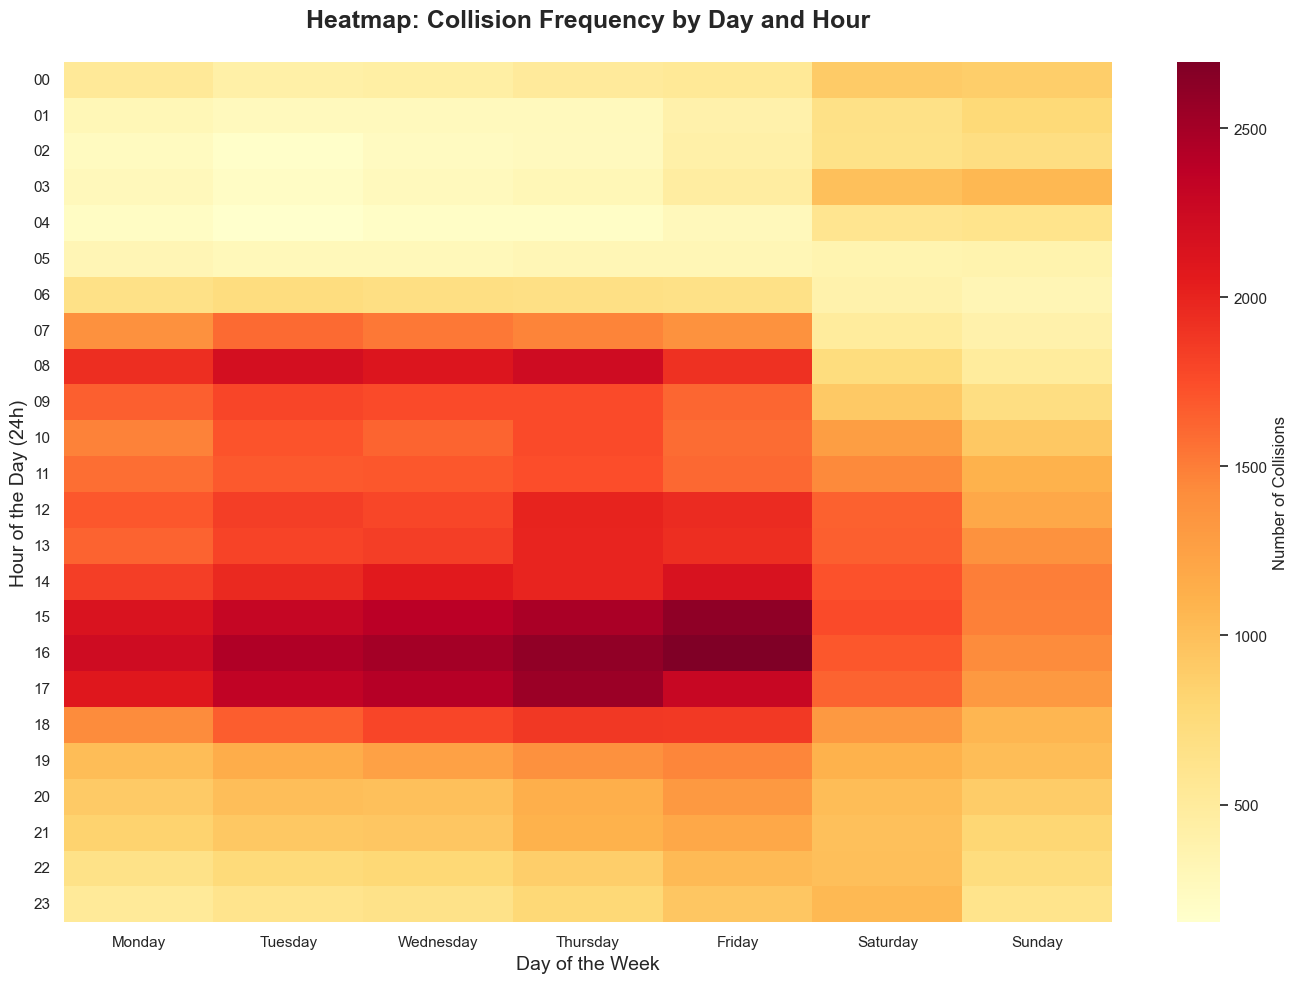

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('collisions_routieres.csv')

# 2. Clean the data
# Remove 'Non précisé' entries and extract the starting hour
df_clean = df[df['HEURE_ACCDN'] != 'Non précisé'].copy()
df_clean['Hour'] = df_clean['HEURE_ACCDN'].str[:2]

# Map the French weekday abbreviations to English full names for clarity
day_map = {
    'LU': 'Monday', 'MA': 'Tuesday', 'ME': 'Wednesday',
    'JE': 'Thursday', 'VE': 'Friday', 'SA': 'Saturday', 'DI': 'Sunday'
}
df_clean['Day'] = df_clean['JR_SEMN_ACCDN'].map(day_map)

# 3. Create a pivot table (Count of collisions for each Day/Hour combination)
# Index = Hour of Day, Columns = Day of Week
heatmap_data = df_clean.pivot_table(index='Hour', columns='Day', values='NO_SEQ_COLL', aggfunc='count')

# Ensure the days are ordered correctly (Monday to Sunday)
days_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data[days_ordered]

# 4. Create the Visualization
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# Use a heatmap with 'YlOrRd' (Yellow-Orange-Red) to show intensity
# Red = High Danger Zone
ax = sns.heatmap(
    heatmap_data, 
    annot=False, 
    cmap='YlOrRd', 
    cbar_kws={'label': 'Number of Collisions'}
)

# 5. Styling and Titles
plt.title('Heatmap: Collision Frequency by Day and Hour', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Hour of the Day (24h)', fontsize=14)

# Keep labels readable
plt.xticks(rotation=0)
plt.yticks(rotation=0)

# Finalize and Save
plt.tight_layout()
plt.savefig('collision_heatmap.png', dpi=300)
plt.show()

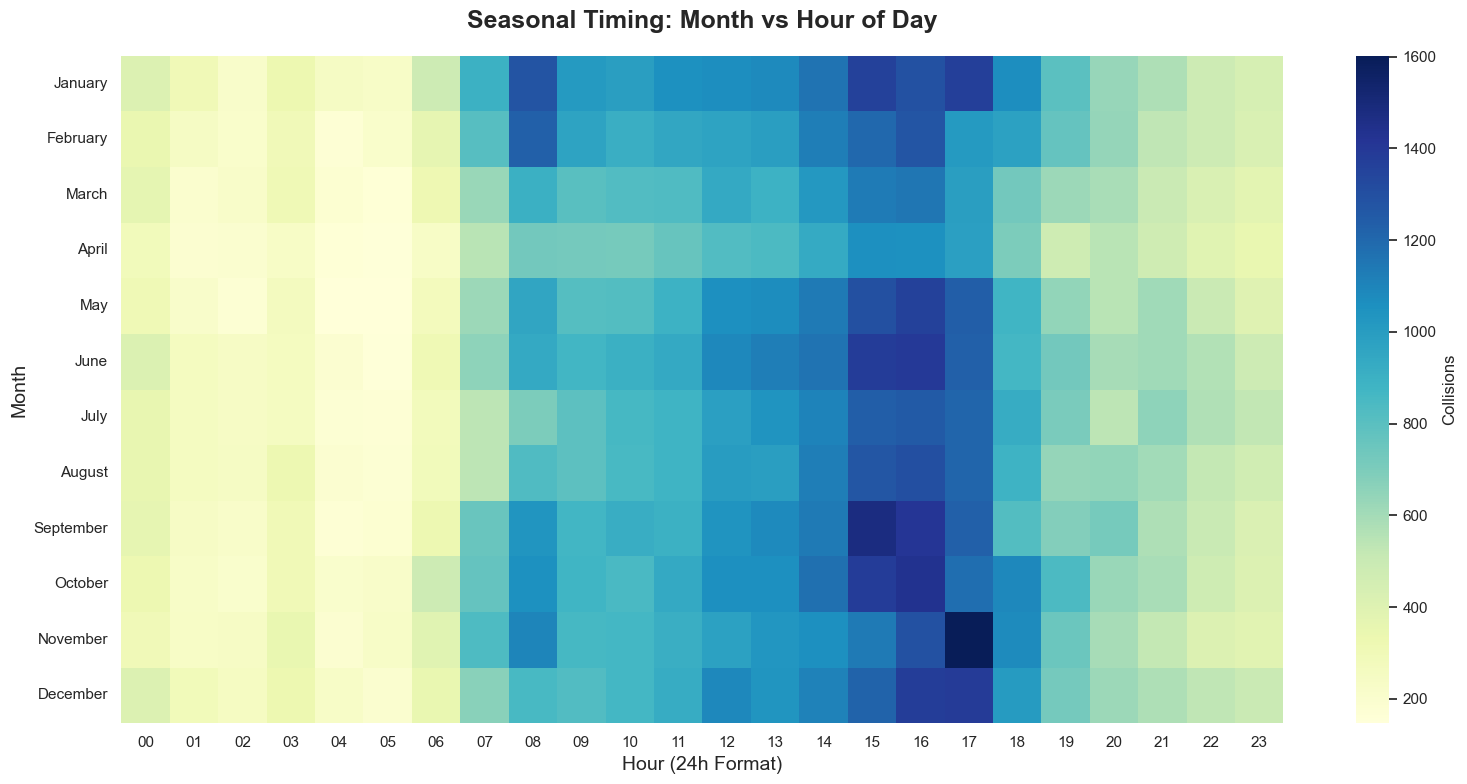

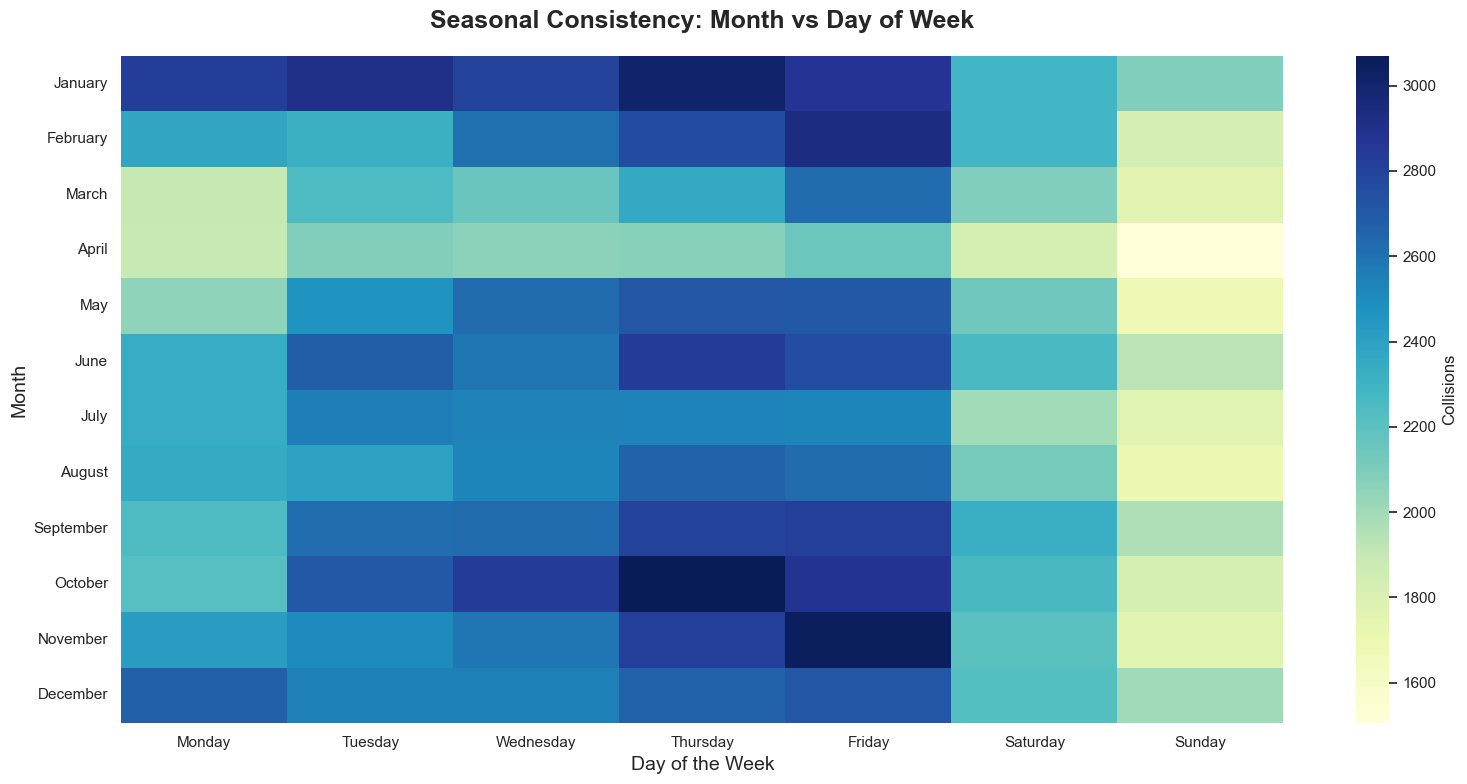

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Preprocess Data
df = pd.read_csv('collisions_routieres.csv')

# Clean time data and extract hour
df_clean = df[df['HEURE_ACCDN'] != 'Non précisé'].copy()
df_clean['Hour'] = df_clean['HEURE_ACCDN'].str[:2]

# Convert date to Month names
df_clean['DT_ACCDN'] = pd.to_datetime(df_clean['DT_ACCDN'])
df_clean['Month_Name'] = df_clean['DT_ACCDN'].dt.month_name()

# Map French day abbreviations to English names
day_map = {
    'LU': 'Monday', 'MA': 'Tuesday', 'ME': 'Wednesday',
    'JE': 'Thursday', 'VE': 'Friday', 'SA': 'Saturday', 'DI': 'Sunday'
}
df_clean['Day'] = df_clean['JR_SEMN_ACCDN'].map(day_map)

# Define logical sorting orders
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Create Pivot Tables
pivot_month_hour = df_clean.pivot_table(
    index='Month_Name', columns='Hour', values='NO_SEQ_COLL', aggfunc='count'
).reindex(month_order)

pivot_month_day = df_clean.pivot_table(
    index='Month_Name', columns='Day', values='NO_SEQ_COLL', aggfunc='count'
).reindex(month_order)[day_order]

# 3. Create First Image: Month vs Hour Heatmap
plt.figure(figsize=(16, 8))
sns.set_theme(style="white")
ax1 = sns.heatmap(pivot_month_hour, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Collisions'})
ax1.set_title('Seasonal Timing: Month vs Hour of Day', fontsize=18, fontweight='bold', pad=20)
ax1.set_xlabel('Hour (24h Format)', fontsize=14)
ax1.set_ylabel('Month', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_month_hour.png', dpi=300)
plt.show()
plt.close() # Close the figure to free memory

# 4. Create Second Image: Month vs Day of Week Heatmap
plt.figure(figsize=(16, 8))
sns.set_theme(style="white")
ax2 = sns.heatmap(pivot_month_day, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Collisions'})
ax2.set_title('Seasonal Consistency: Month vs Day of Week', fontsize=18, fontweight='bold', pad=20)
ax2.set_xlabel('Day of the Week', fontsize=14)
ax2.set_ylabel('Month', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_month_day.png', dpi=300)
plt.show()
plt.close()